In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/bout")

In [3]:
from core import SITE_NAMES, FREQ_GROUPS
import clustering as clstr
import bout.assembly as bt
import bout.clustering as clstr
import plot as bt_plt
import activity.subsampling as ss
import activity.activity_assembly as actvt
import pipeline

from cli import get_file_paths

In [4]:
site_key = 'Foliage'
freq_key = 'HF'

bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key

fig_details = dict()
fig_details['site_name'] = SITE_NAMES[site_key]
fig_details['freq_group'] = freq_key.split('_')[0].upper()
if freq_key:
    fig_details['freq_group'] = fig_details['freq_group'] + ' '
fig_details['bin_step'] = 10
fig_details['time_end'] = 1000
print(f'Looking at {fig_details["site_name"]}')
HF_location_df = pd.read_csv(f'../data/2022_detector_summaries/{bout_params["site_key"]}/bd2__{bout_params["freq_key"]}{bout_params["site_key"]}_2022_kmeans.csv', index_col=0, dtype='object')

Looking at Foliage


Foliage HF Min: 26880.0
Foliage HF Max: 79680.0
Foliage HF Median: 44160.0
Foliage HF Mean: 44564.0523703293


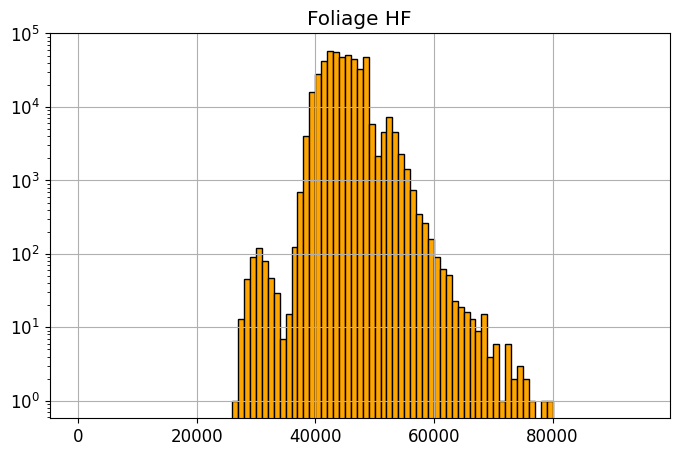

In [5]:
stat_arr = HF_location_df.peak_frequency.astype(float)
print(f"{site_key} {freq_key} Min: {stat_arr.min()}")
print(f"{site_key} {freq_key} Max: {stat_arr.max()}")
print(f"{site_key} {freq_key} Median: {stat_arr.median()}")
print(f"{site_key} {freq_key} Mean: {stat_arr.mean()}")

plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size':12})
plt.title(f'{site_key} {freq_key}')
plt.hist(stat_arr, bins=np.arange(0, 96000, 1000), facecolor='orange', edgecolor='k')
plt.yscale('log')
plt.grid(which='major')
plt.show()

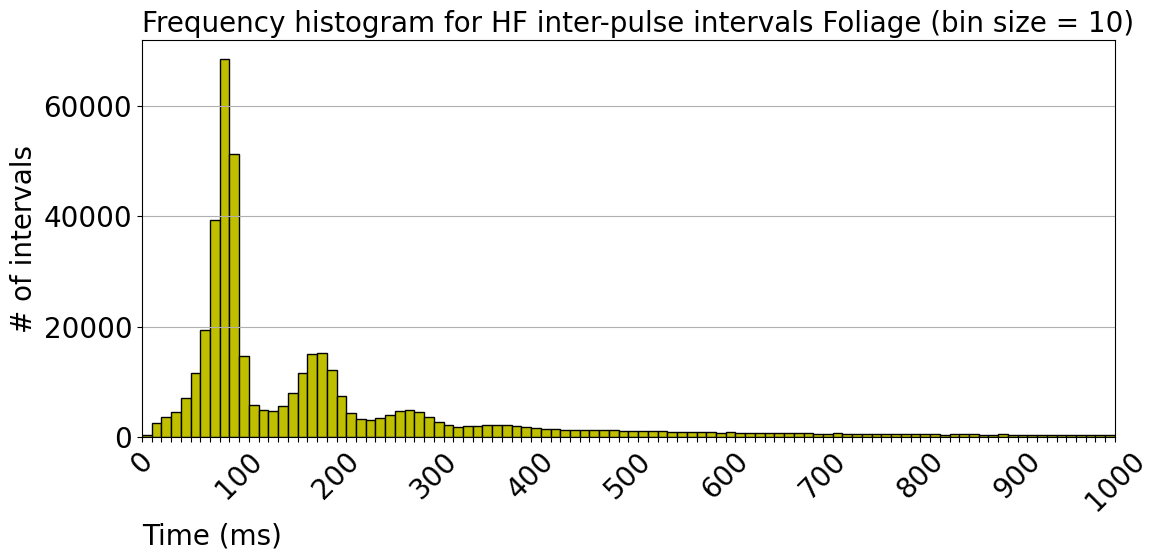

In [6]:
ipis_f, hist_f = bt_plt.plot_ipi_hist(HF_location_df.copy(), fig_details)

In [7]:
freq_key = 'LF'

bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key

fig_details = dict()
fig_details['site_name'] = SITE_NAMES[site_key]
fig_details['freq_group'] = freq_key.split('_')[0].upper()
if freq_key:
    fig_details['freq_group'] = fig_details['freq_group'] + ' '
fig_details['bin_step'] = 10
fig_details['time_end'] = 1000
print(f'Looking at {fig_details["site_name"]}')
LF_location_df = pd.read_csv(f'../data/2022_detector_summaries/{bout_params["site_key"]}/bd2__{bout_params["freq_key"]}{bout_params["site_key"]}_2022_kmeans.csv', index_col=0, dtype='object')

Looking at Foliage


Foliage LF Min: 11520.0
Foliage LF Max: 38400.0
Foliage LF Median: 26880.0
Foliage LF Mean: 26753.6229340007


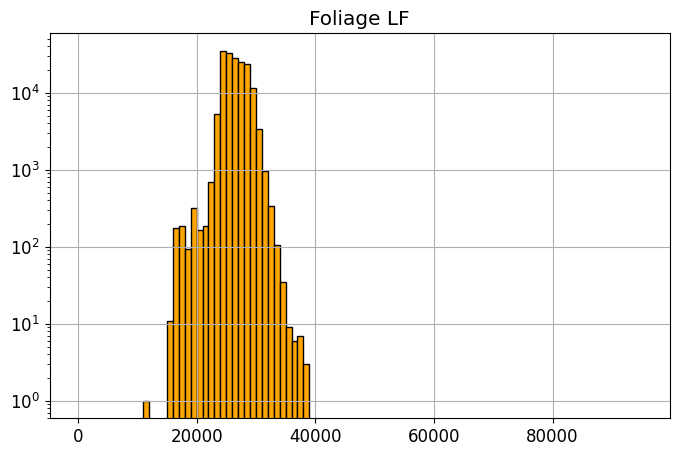

In [8]:
stat_arr = LF_location_df.peak_frequency.astype(float)
print(f"{site_key} {freq_key} Min: {stat_arr.min()}")
print(f"{site_key} {freq_key} Max: {stat_arr.max()}")
print(f"{site_key} {freq_key} Median: {stat_arr.median()}")
print(f"{site_key} {freq_key} Mean: {stat_arr.mean()}")

plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size':12})
plt.title(f'{site_key} {freq_key}')
plt.hist(stat_arr, bins=np.arange(0, 96000, 1000), facecolor='orange', edgecolor='k')
plt.yscale('log')
plt.grid(which='major')
plt.show()

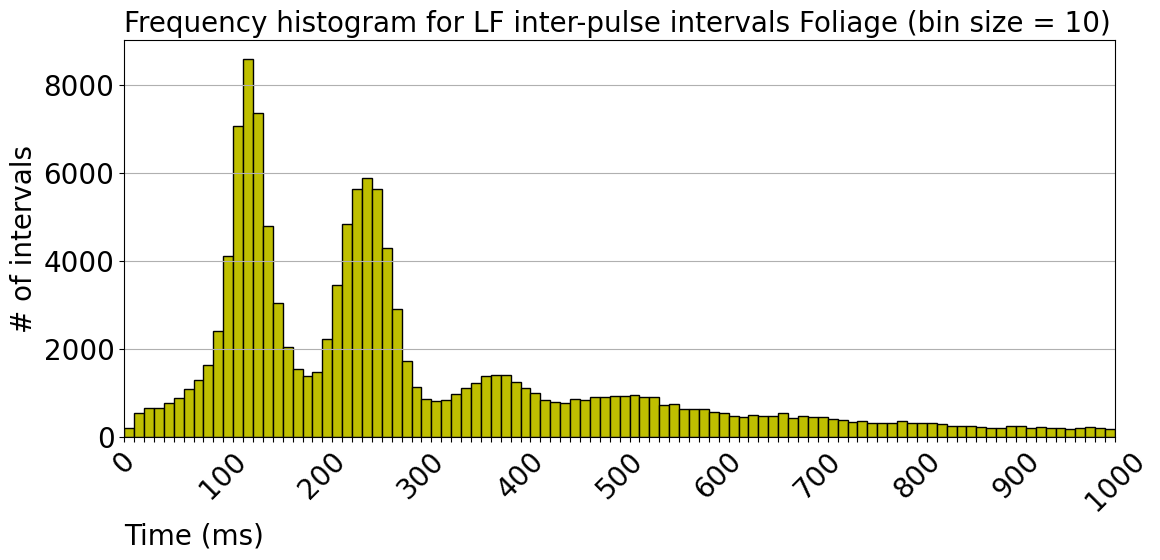

In [9]:
ipis_f, hist_f = bt_plt.plot_ipi_hist(LF_location_df.copy(), fig_details)

Foliage LF Min: 11520.0
Foliage LF Max: 38400.0
Foliage LF Median: 26880.0
Foliage LF Mean: 26753.6229340007
Foliage HF Min: 26880.0
Foliage HF Max: 79680.0
Foliage HF Median: 44160.0
Foliage HF Mean: 44564.0523703293


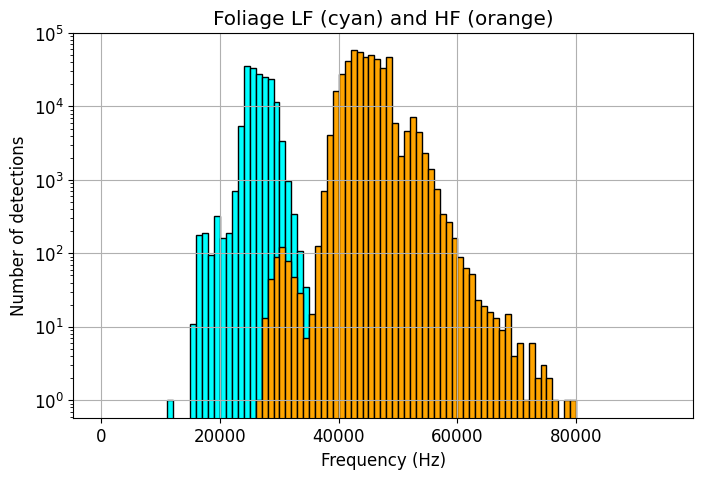

In [10]:
freq_key = "LF"
stat_arr = LF_location_df.peak_frequency.astype(float)
print(f"{site_key} {freq_key} Min: {stat_arr.min()}")
print(f"{site_key} {freq_key} Max: {stat_arr.max()}")
print(f"{site_key} {freq_key} Median: {stat_arr.median()}")
print(f"{site_key} {freq_key} Mean: {stat_arr.mean()}")

plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size':12})
plt.title(f'{site_key} LF (cyan) and HF (orange)')
plt.hist(stat_arr, bins=np.arange(0, 96000, 1000), facecolor='cyan', edgecolor='k')
plt.yscale('log')
plt.grid(which='major')

freq_key = 'HF'
stat_arr = HF_location_df.peak_frequency.astype(float)
print(f"{site_key} {freq_key} Min: {stat_arr.min()}")
print(f"{site_key} {freq_key} Max: {stat_arr.max()}")
print(f"{site_key} {freq_key} Median: {stat_arr.median()}")
print(f"{site_key} {freq_key} Mean: {stat_arr.mean()}")

plt.hist(stat_arr, bins=np.arange(0, 96000, 1000), facecolor='orange', edgecolor='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Number of detections')
plt.show()